# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'nraja3'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.08 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

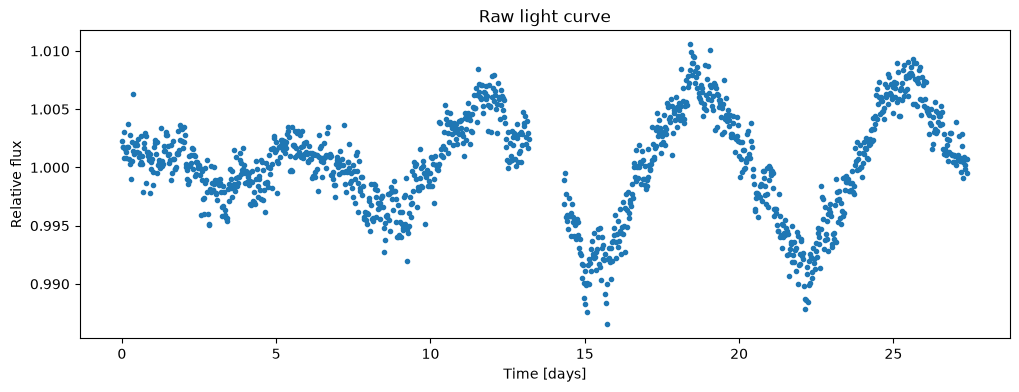

In [17]:
# Part 1: your work here
plt.figure(figsize=(12, 4))
plt.plot(t, flux, '.')
plt.xlabel('Time [days]')
plt.ylabel('Relative flux')
plt.title('Raw light curve')
plt.show()

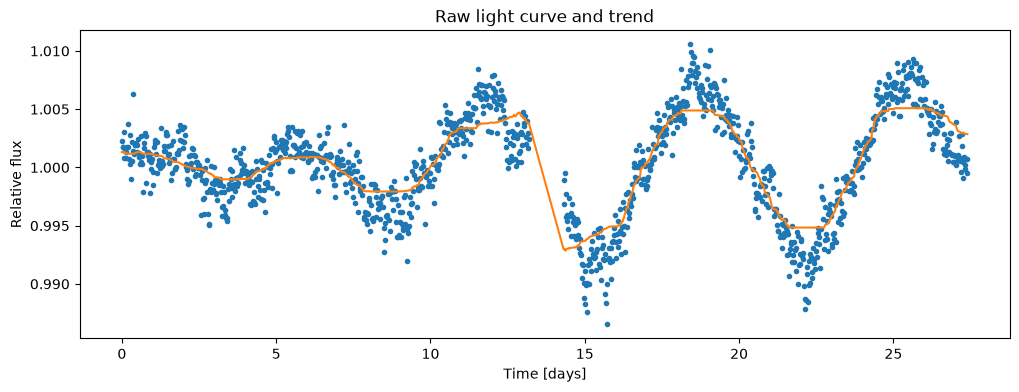

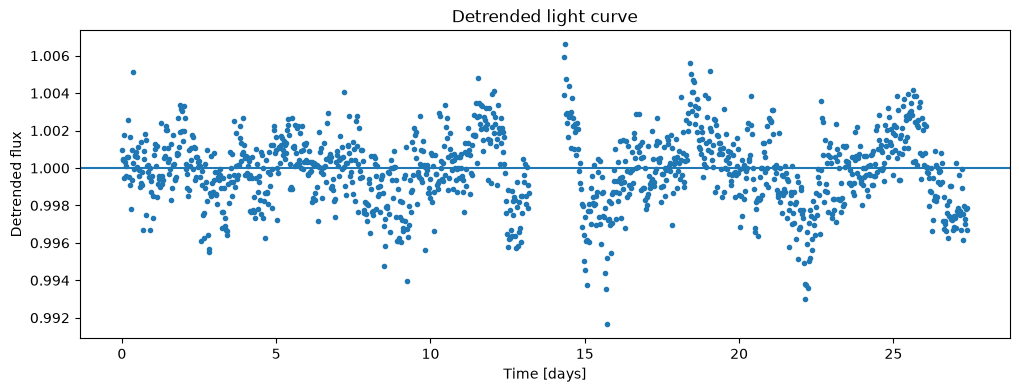

In [18]:
differences = np.diff(t)

gap = np.argmax(differences) + 1
trend = np.zeros(len(flux))

half = 72

for i in range(gap):
    start = i - half
    end = i + half + 1
    if start < 0:
        start = 0
    if end > gap:
        end = gap
    trend[i] = np.median(flux[start:end])

for i in range(gap, len(flux)):
    start = i - half
    end = i + half + 1
    if start < gap:
        start = gap
    if end > len(flux):
        end = len(flux)
    trend[i] = np.median(flux[start:end])

flux_det = flux / trend
sigma_det = sigma / trend

plt.figure(figsize=(12, 4))
plt.plot(t, flux, '.')
plt.plot(t, trend)
plt.xlabel('Time [days]')
plt.ylabel('Relative flux')
plt.title('Raw light curve and trend')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, flux_det, '.')
plt.axhline(1)
plt.xlabel('Time [days]')
plt.ylabel('Detrended flux')
plt.title('Detrended light curve')
plt.show()

**2.**
*I detrended this curve using a median filter on each side of the gap. I used a smoothing scale of approximately 72 hours on either side of each point, which is 3 days. Since the median is determined by the majority of points in the range, few low transit points cannot significantly affect the trend.*

In [19]:
t0_guess = 3
period_guess = 7
depth_guess = 0.004
duration_guess = 0.10

phase_guess = ((t - t0_guess + 0.5 * period_guess) % period_guess) - 0.5 * period_guess
outside = np.abs(phase_guess) > 0.2
scatter = np.std(flux_det[outside] - 1)
stated = np.mean(sigma_det)

print("Observed scatter =", scatter * 1000, "ppt")
print("Stated sigma =", stated * 1000, "ppt")

Observed scatter = 1.9630300341326747 ppt
Stated sigma = 1.0776044761415882 ppt


**ANSWERS (initial guesses + scatter check):**

*t_0 guess = 3 days*

*period guess = 7 days*

*depth guess = 0.004*

*duration guess = 0.10 days*

**4.** 
*The out-of-transit scatter is around 1.963, which is larger than the stated sigma of around 1.0776, so I would say it is not fully consistent to describe the noise in the light curve.*

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

t0 = 2.813213366990748
Period = 6.443709545297411
Depth = 5.287219323054721 ppt
Duration = 0.10444582697352592
Baseline = 0.999930303603088


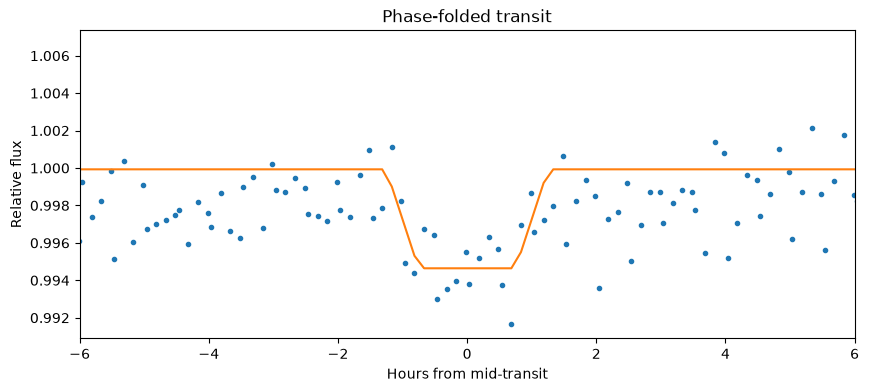

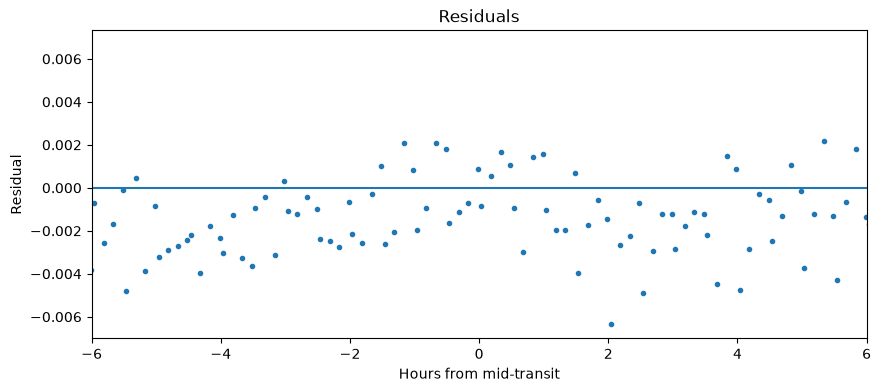

In [20]:
# Part 2: your work here

def nll(p, y=flux_det):
    t0 = p[0]
    period = p[1]
    depth = p[2]
    duration = p[3]
    baseline = p[4]
    if period <= 0 or depth <= 0 or duration <= 0:
        return 1e100
    model_fit = transit_model(t, t0, period, depth, duration, baseline)
    return 0.5 * np.sum(((y - model_fit) / sigma_det) ** 2)

guess1 = [3.0, 6.5, 0.004, 0.10, 1.0]
guess2 = [2.8, 6.45, 0.004, 0.10, 1.0]

result1 = minimize(nll, guess1, method='Nelder-Mead')
result2 = minimize(nll, guess2, method='Nelder-Mead')

if result1.fun < result2.fun:
    result = result1
else:
    result = result2

best = result.x
t0 = best[0]
period = best[1]
depth = best[2]
duration = best[3]
baseline = best[4]

print("t0 =", t0)
print("Period =", period)
print("Depth =", depth * 1000, "ppt")
print("Duration =", duration)
print("Baseline =", baseline)

model = transit_model(t, t0, period, depth, duration, baseline)
phase = ((t - t0 + 0.5 * period) % period) - 0.5 * period
order = np.argsort(phase)
residuals = flux_det - model

plt.figure(figsize=(10, 4))
plt.plot(phase[order] * 24, flux_det[order], '.')
plt.plot(phase[order] * 24, model[order])
plt.xlim(-6, 6)
plt.xlabel('Hours from mid-transit')
plt.ylabel('Relative flux')
plt.title('Phase-folded transit')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(phase[order] * 24, residuals[order], '.')
plt.axhline(0)
plt.xlim(-6, 6)
plt.xlabel('Hours from mid-transit')
plt.ylabel('Residual')
plt.title('Residuals')
plt.show()

In [21]:
def hessian(f, x, step):
    n = len(x)
    H = np.zeros((n, n))
    f0 = f(x)
    for i in range(n):
        ei = np.zeros(n)
        ei[i] = step[i]
        H[i, i] = (f(x + ei) - 2 * f0 + f(x - ei)) / step[i] ** 2
        for j in range(i + 1, n):
            ej = np.zeros(n)
            ej[j] = step[j]
            H[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * step[i] * step[j])
            H[j, i] = H[i, j]
    return H

step = np.array([0.001, 0.001, 0.00001, 0.001, 0.00001])
H = hessian(nll, best, step)
cov = np.linalg.inv(H)
hessian_error = np.sqrt(np.diag(cov))

print("Hessian depth error =", hessian_error[2] * 1000, "ppt")

Hessian depth error = 0.30566689780116924 ppt


In [22]:
residuals = residuals - np.mean(residuals)
B = 100
point_results = np.zeros((B, 5))

for i in range(B):
    new_residuals = np.random.choice(residuals, len(residuals), replace=True)
    new_flux = model + new_residuals
    fit = minimize(nll, best, args=(new_flux,), method='Nelder-Mead')
    point_results[i] = fit.x

point_error = np.std(point_results, axis=0, ddof=1)

print("Point bootstrap depth error =", point_error[2] * 1000, "ppt")

Point bootstrap depth error = 0.5025361664811395 ppt


In [23]:
block_size = 48
blocks = []

for i in range(len(residuals) - block_size + 1):
    if t[i + block_size - 1] - t[i] < 1.1:
        blocks.append(residuals[i:i + block_size])

block_results = np.zeros((B, 5))

for i in range(B):
    new_residuals = []
    while len(new_residuals) < len(residuals):
        k = np.random.randint(len(blocks))
        new_residuals.extend(blocks[k])
    new_residuals = np.array(new_residuals[:len(residuals)])
    new_flux = model + new_residuals
    fit = minimize(nll, best, args=(new_flux,), method='Nelder-Mead')
    block_results[i] = fit.x

block_error = np.std(block_results, axis=0, ddof=1)

print("Block bootstrap depth error =", block_error[2] * 1000, "ppt")

Block bootstrap depth error = 0.7179201192459582 ppt


In [24]:
bin_residuals = []

i = 0

while i + 10 <= len(residuals):
    if t[i + 9] - t[i] < 0.3:
        bin_residuals.append(np.mean(residuals[i:i + 10]))
    i = i + 10

bin_residuals = np.array(bin_residuals)

scatter = np.std(residuals, ddof=1)
observed = np.std(bin_residuals, ddof=1)
expected = scatter / np.sqrt(10)

print("Observed 5-hour scatter =", observed * 1000, "ppt")
print("Expected 5-hour scatter =", expected * 1000, "ppt")

print("Depth =", depth * 1000, "+/-", block_error[2] * 1000, "ppt")
print("Period =", period, "+/-", block_error[1], "days")
print("t0 =", t0, "+/-", block_error[0], "days")

Observed 5-hour scatter = 1.3737257503914464 ppt
Expected 5-hour scatter = 0.5845303598630708 ppt
Depth = 5.287219323054721 +/- 0.7179201192459582 ppt
Period = 6.443709545297411 +/- 0.0025950736171972055 days
t0 = 2.813213366990748 +/- 0.004583808649339356 days


**FINAL ANSWER:** $\delta = $ 5.287 $\pm$ 0.721 ppt, $P = $ 6.44371 $\pm$ 0.00242 d, $t_0 = $ 2.81321 $\pm$ 0.00473 d

**Which uncertainty and why (a short paragraph):**

*I chose the block bootstrap because the residuals show time-correlated noise. The observed scatter is much bigger than expected for independent noise which means not all the points are fully independent. So, block bootstrap uncertainties are better because it keeps neighboring residuals together.*

*The Hessian gives the smallest uncertainty, followed by the point bootstrap and then the block bootstrap. The Hessian and point bootstrap assume independent noise, but the residuals are time-correlated. This is why the block bootstrap gives the largest uncertainty.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1: The AI uses a 6-hour detrending window, which is too close to the 2–3 hour transit duration. This can remove part of the transit signal since the window is short. A longer window is better.*

*Flaw 2: The AI uses the scatter of the same detrended data to estimate the noise, then uses that noise to check reduced chi-squared. That makes the check partly circular. The stated sigma_flux should be used in the likelihood instead.*

*Flaw 3: The AI only uses curvature in the depth direction and ignores time-correlated noise. My 5-hour bins show more scatter than independent noise predicts, so the block bootstrap gives a more realistic uncertainty.*

In [25]:
# Part 3: demonstrations here

# Flaw 1
tr = np.zeros(len(flux))
h = 6

for i in range(len(flux)):
    s = i - h
    e = i + h + 1
    if i < gap:
        if s < 0:
            s = 0
        if e > gap:
            e = gap
    else:
        if s < gap:
            s = gap
        if e > len(flux):
            e = len(flux)
    tr[i] = np.median(flux[s:e])

fd = flux / tr
fit = minimize(nll, best, args=(fd,), method='Nelder-Mead')

print("6-hour depth =", fit.x[2] * 1000, "ppt")
print("1-day depth =", depth * 1000, "ppt")
print("6-hour duration =", fit.x[3] * 24, "hours")
print("1-day duration =", duration * 24, "hours")

6-hour depth = 2.7449868364871035 ppt
1-day depth = 5.287219323054721 ppt
6-hour duration = 2.232033601714363 hours
1-day duration = 2.5066998473646223 hours


In [26]:
# Flaw 2
se = np.std(fd)
ss = sigma / tr
m = transit_model(t, *fit.x)
r = fd - m

ce = np.sum((r / se) ** 2) / (len(t) - 5)
cs = np.sum((r / ss) ** 2) / (len(t) - 5)

print("AI empirical sigma =", se * 1000, "ppt")
print("Stated sigma =", np.mean(ss) * 1000, "ppt")
print("Reduced chi squared using empirical sigma =", ce)
print("Reduced chi squared using stated sigma =", cs)

AI empirical sigma = 1.2082016982270014 ppt
Stated sigma = 1.0777312180288543 ppt
Reduced chi squared using empirical sigma = 0.9504632330827626
Reduced chi squared using stated sigma = 1.1938933406897347


In [27]:
# Flaw 3
h = depth * 0.001

p1 = best.copy()
p2 = best.copy()

p1[2] = depth + h
p2[2] = depth - h

curvature = (nll(p1) - 2 * nll(best) + nll(p2)) / h ** 2
ai_depth_error = 1 / np.sqrt(curvature)

print("AI-style depth error =", ai_depth_error * 1000, "ppt")
print("Full Hessian depth error =", hessian_error[2] * 1000, "ppt")
print("Point bootstrap depth error =", point_error[2] * 1000, "ppt")
print("Block bootstrap depth error =", block_error[2] * 1000, "ppt")
print("Observed 5-hour scatter =", observed * 1000, "ppt")
print("Expected independent scatter =", expected * 1000, "ppt")

AI-style depth error = 0.2835746816720958 ppt
Full Hessian depth error = 0.30566689780116924 ppt
Point bootstrap depth error = 0.5025361664811395 ppt
Block bootstrap depth error = 0.7179201192459582 ppt
Observed 5-hour scatter = 1.3737257503914464 ppt
Expected independent scatter = 0.5845303598630708 ppt


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

*I used ChatGPT mainly to help write and simplify the code for the Hessian and bootstraps. I also used it to help fix coding errors. One mistake in an earlier version was that the likelihood used flux_det instead of the new resampled y value, which would have made the bootstrap incorrect. I ran the code myself and checked the outputs before using the results.*

**VERIFICATION PLAN:**

*I plotted the phase-folded light curve and best-fit model. A failure would be if the model did not line up with the transit.*

*I plotted the residuals. A failure would be the residuals not being centered near zero.*

*I compared the Hessian, point bootstrap, and block bootstrap uncertainties. A failure would be unrealistic uncertainty values.*

*I binned the residuals into about 5-hour groups and compared the scatter with independent-noise predictions. The larger observed scatter showed that the noise is correlated, which is why I trusted the block bootstrap more.*